# Stretch Window Results
Recreated table and plots for the CNN and SVM metrics across window lengths.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Recreated metrics from the provided table.
seconds = [2, 1.5, 1, 0.5, 0.25]
frames = [188, 140, 93, 46, 23]

cnn = {
    "accuracy": [1, 1, 0.997222, 0.677778, 0.273611],
    "precision": [1, 1, 0.997354, 0.767631, 0.283493],
    "recall": [1, 1, 0.997222, 0.677778, 0.273611],
    "f1-score": [1, 1, 0.99722, 0.662006, 0.217198],
}

svm = {
    "accuracy": [0.998611, 0.998611, 0.920833, 0.026389, 0.026389],
    "precision": [0.998677, 0.998677, 0.946866, 0.000734, 0.000734],
    "recall": [0.998611, 0.998611, 0.920833, 0.026389, 0.026389],
    "f1-score": [0.99861, 0.99861, 0.922062, 0.001428, 0.001428],
}

columns = pd.MultiIndex.from_product(
    [["CNN Model", "SVM Model"], ["accuracy", "precision", "recall", "f1-score"]],
    names=["model", "metric"],
)

df = pd.DataFrame(index=seconds, columns=columns, dtype=float)
df.index.name = "seconds"
df.insert(0, "frames", frames)

for metric in cnn:
    df[("CNN Model", metric)] = cnn[metric]
    df[("SVM Model", metric)] = svm[metric]

df_rounded = df.round(6)
df_rounded

model   frames CNN Model                               SVM Model            \
metric          accuracy precision    recall  f1-score  accuracy precision   
seconds                                                                      
2.00       188  1.000000  1.000000  1.000000  1.000000  0.998611  0.998677   
1.50       140  1.000000  1.000000  1.000000  1.000000  0.998611  0.998677   
1.00        93  0.997222  0.997354  0.997222  0.997220  0.920833  0.946866   
0.50        46  0.677778  0.767631  0.677778  0.662006  0.026389  0.000734   
0.25        23  0.273611  0.283493  0.273611  0.217198  0.026389  0.000734   

model                        
metric     recall  f1-score  
seconds                      
2.00     0.998611  0.998610  
1.50     0.998611  0.998610  
1.00     0.920833  0.922062  
0.50     0.026389  0.001428  
0.25     0.026389  0.001428

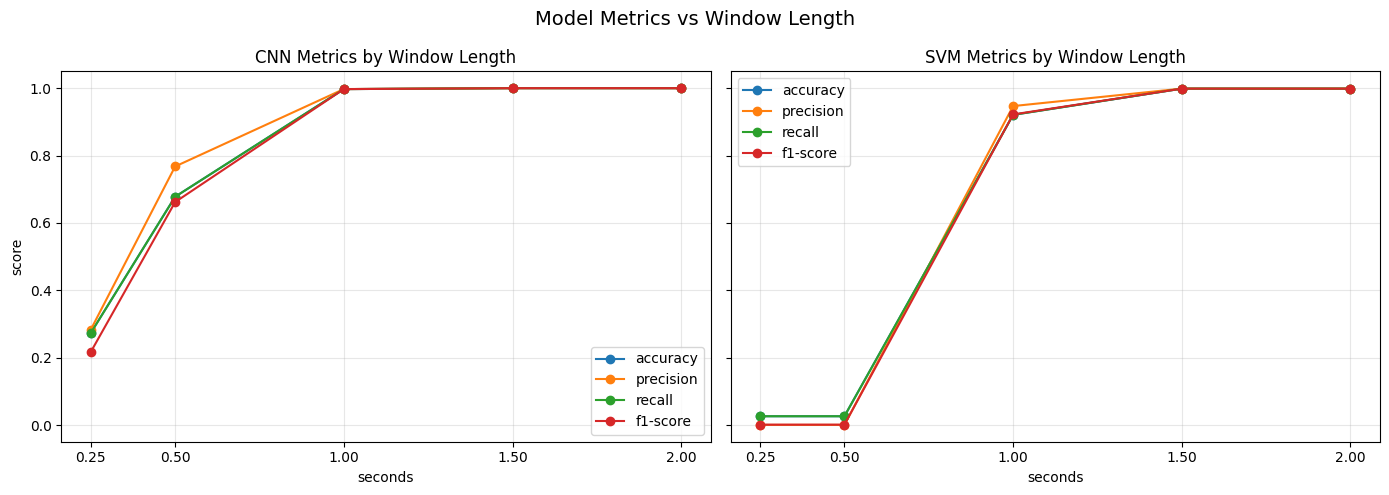

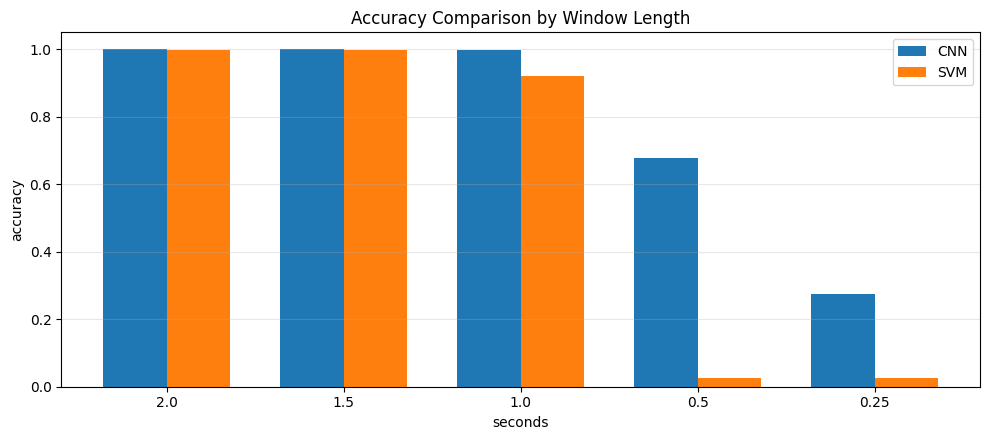

In [3]:
metrics = ["accuracy", "precision", "recall", "f1-score"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for metric in metrics:
    axes[0].plot(df.index, df[("CNN Model", metric)], marker="o", label=metric)
axes[0].set_title("CNN Metrics by Window Length")
axes[0].set_xlabel("seconds")
axes[0].set_ylabel("score")
axes[0].set_xticks(df.index)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for metric in metrics:
    axes[1].plot(df.index, df[("SVM Model", metric)], marker="o", label=metric)
axes[1].set_title("SVM Metrics by Window Length")
axes[1].set_xlabel("seconds")
axes[1].set_xticks(df.index)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle("Model Metrics vs Window Length", fontsize=14)
fig.tight_layout()

# Side-by-side accuracy comparison for quick model contrast.
x = np.arange(len(df.index))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width / 2, df[("CNN Model", "accuracy")], width, label="CNN")
ax.bar(x + width / 2, df[("SVM Model", "accuracy")], width, label="SVM")
ax.set_title("Accuracy Comparison by Window Length")
ax.set_xlabel("seconds")
ax.set_ylabel("accuracy")
ax.set_xticks(x)
ax.set_xticklabels(df.index)
ax.set_ylim(0, 1.05)
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()

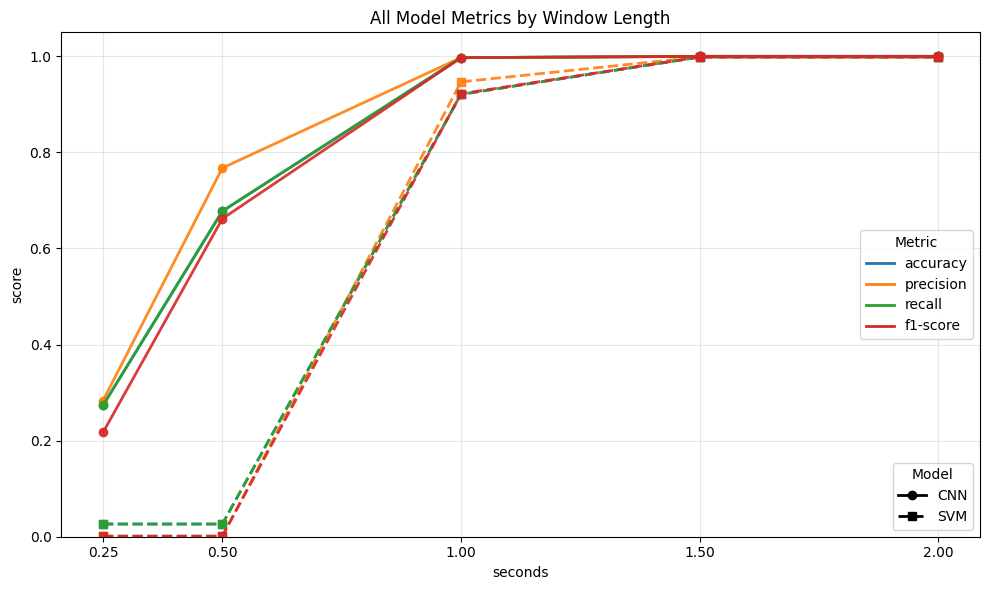

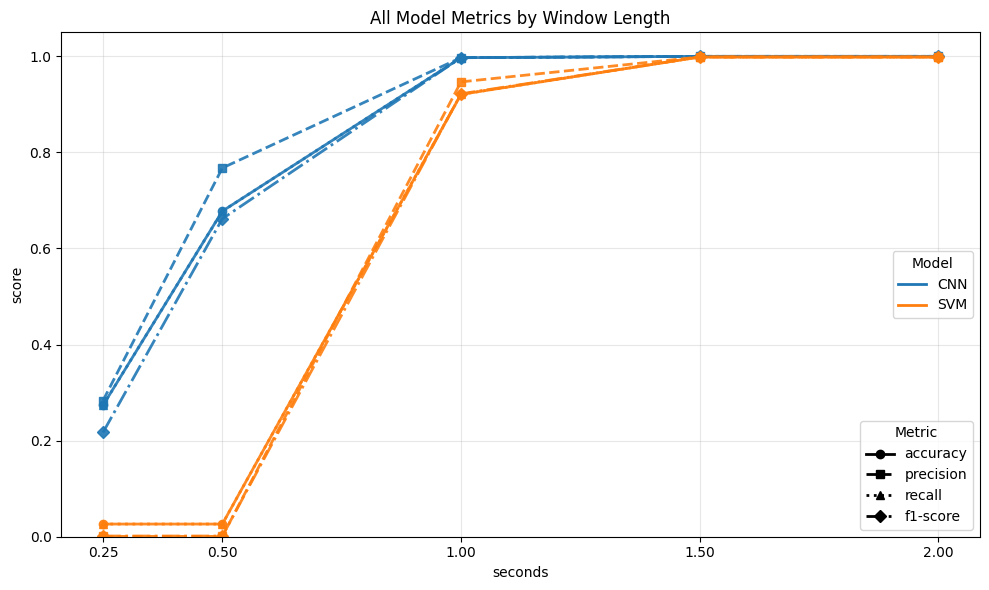

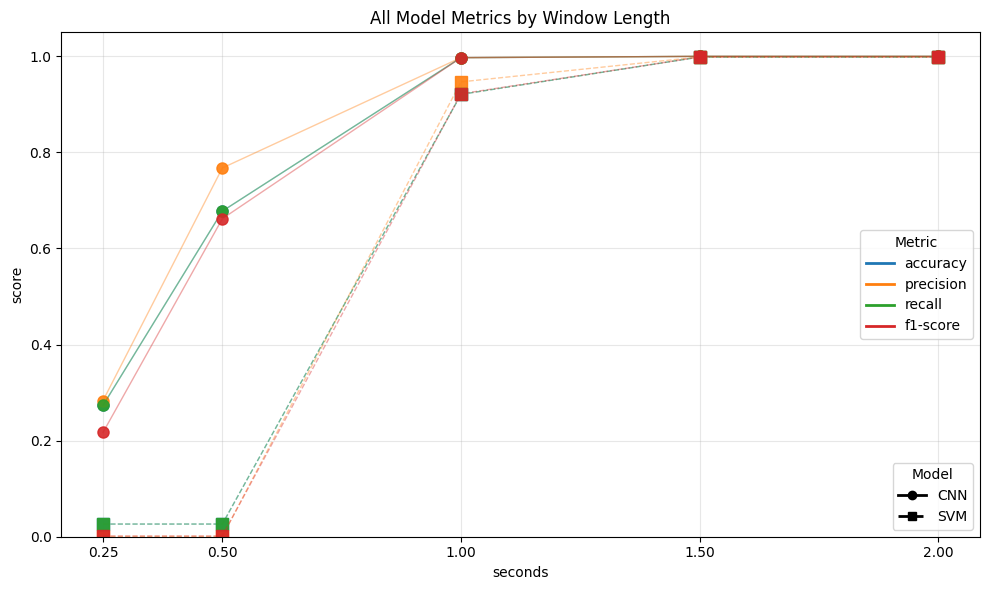

In [8]:
from matplotlib.lines import Line2D

# Sort the x-axis for readability without changing the source table.
df_plot = df.sort_index()
x = df_plot.index.tolist()

metrics = ["accuracy", "precision", "recall", "f1-score"]
models = [("CNN Model", "CNN"), ("SVM Model", "SVM")]

# Main combined plot: color encodes metric, line style encodes model.
metric_colors = dict(zip(metrics, plt.cm.tab10.colors[: len(metrics)]))
model_linestyles = {"CNN": "-", "SVM": "--"}
model_markers = {"CNN": "o", "SVM": "s"}

fig, ax = plt.subplots(figsize=(10, 6))
for metric in metrics:
    for model_key, model_label in models:
        ax.plot(
            x,
            df_plot[(model_key, metric)],
            color=metric_colors[metric],
            linestyle=model_linestyles[model_label],
            marker=model_markers[model_label],
            linewidth=2,
            markersize=6,
            alpha=0.9,
        )

ax.set_title("All Model Metrics by Window Length")
ax.set_xlabel("seconds")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.grid(True, alpha=0.3)

metric_handles_main = [
    Line2D([0], [0], color=metric_colors[m], lw=2, label=m) for m in metrics
 ]
model_handles_main = [
    Line2D(
        [0],
        [0],
        color="black",
        lw=2,
        linestyle=model_linestyles[label],
        marker=model_markers[label],
        label=label,
    )
    for label in ["CNN", "SVM"]
 ]
legend_metrics = ax.legend(handles=metric_handles_main, title="Metric", loc="center right")
ax.add_artist(legend_metrics)
ax.legend(handles=model_handles_main, title="Model", loc="lower right")
fig.tight_layout()

# Alternative A: color encodes model, line style and marker encode metric.
model_colors = {"CNN": "#1f77b4", "SVM": "#ff7f0e"}
metric_linestyles = {"accuracy": "-", "precision": "--", "recall": ":", "f1-score": "-."}
metric_markers = {"accuracy": "o", "precision": "s", "recall": "^", "f1-score": "D"}

fig, ax = plt.subplots(figsize=(10, 6))
for model_key, model_label in models:
    for metric in metrics:
        ax.plot(
            x,
            df_plot[(model_key, metric)],
            color=model_colors[model_label],
            linestyle=metric_linestyles[metric],
            marker=metric_markers[metric],
            linewidth=2,
            markersize=6,
            alpha=0.9,
        )

ax.set_title("All Model Metrics by Window Length")
ax.set_xlabel("seconds")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.grid(True, alpha=0.3)

model_handles_alt = [
    Line2D([0], [0], color=model_colors[m], lw=2, label=m) for m in ["CNN", "SVM"]
 ]
metric_handles_alt = [
    Line2D(
        [0],
        [0],
        color="black",
        lw=2,
        linestyle=metric_linestyles[m],
        marker=metric_markers[m],
        label=m,
    )
    for m in metrics
 ]
legend_models = ax.legend(handles=model_handles_alt, title="Model", loc="center right")
ax.add_artist(legend_models)
ax.legend(handles=metric_handles_alt, title="Metric", loc="lower right")
fig.tight_layout()

# Alternative B: marker-only emphasis to reduce line clutter.
fig, ax = plt.subplots(figsize=(10, 6))
for metric in metrics:
    for model_key, model_label in models:
        ax.plot(
            x,
            df_plot[(model_key, metric)],
            color=metric_colors[metric],
            linestyle="none",
            marker=model_markers[model_label],
            markersize=8,
            alpha=0.9,
        )
        ax.plot(
            x,
            df_plot[(model_key, metric)],
            color=metric_colors[metric],
            linestyle=model_linestyles[model_label],
            linewidth=1,
            alpha=0.4,
        )

ax.set_title("All Model Metrics by Window Length")
ax.set_xlabel("seconds")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.grid(True, alpha=0.3)

legend_metrics = ax.legend(handles=metric_handles_main, title="Metric", loc="center right")
ax.add_artist(legend_metrics)
ax.legend(handles=model_handles_main, title="Model", loc="lower right")
fig.tight_layout()